# 01. Rentabilidades

Obetenemos las rentabilidades diárias de los seis tipos de activos
(precio de hoy / precio de ayer) - 1 

De cada activo queremos saber dos cosas:

- **Rentabilidad media**
- **Volatilidad**

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargo los precios guardados en el notebook anterior
precios = pd.read_csv("../data/precios.csv", index_col="Date", parse_dates=True)

# pct_change calcula (precio de hoy / precio de ayer) - 1 para cada activo
rentabilidades = precios.pct_change().dropna()

rentabilidades.head()

,AGG,EEM,EFA,GLD,SPY,VNQ
Date,,,,,,
2016-01-05,0.000463,0.002236,-0.001557,0.002819,0.001691,0.019297
2016-01-06,0.003795,-0.019120,-0.016456,0.014441,-0.012614,-0.002740
2016-01-07,-0.000092,-0.030864,-0.020782,0.014140,-0.023991,-0.019483
2016-01-08,0.002213,-0.010728,-0.012050,-0.004428,-0.010977,-0.013374
2016-01-11,-0.002853,-0.000339,0.004187,-0.008895,0.000990,0.005680


Un activo puede ganar lo mismo que otro pero con mayor volatilidad, con Markowitz buscamos la mayor rentabilidad con menor volatilidad. Los datos son diarios, pero nos interesa verlos por año. Para eso se usan 252 días de mercado al año.

In [89]:
# Anualizo con 252 días de mercado al año
rentabilidad_anual = rentabilidades.mean() * 252
volatilidad_anual = rentabilidades.std() * (252 ** 0.5) # la desviación típica escala con la raíz del tiempo

resumen = pd.DataFrame({
    "Rentabilidad anual": rentabilidad_anual,
    "Volatilidad anual": volatilidad_anual,
})

# Premio por unidad de susto
resumen["Rentab. / riesgo"] = resumen["Rentabilidad anual"] / resumen["Volatilidad anual"]

resumen.round(3)

,Rentabilidad anual,Volatilidad anual,Rentab. / riesgo
AGG,0.021,0.054,0.393
EEM,0.099,0.203,0.487
EFA,0.096,0.172,0.556
GLD,0.146,0.148,0.988
SPY,0.155,0.180,0.863
VNQ,0.073,0.208,0.353


Podemos observar que los dos mejores activos serían el oro y el SP500 por su volatilidad média y grandes rentabilidades.

### Matriz de covarianzas y correlaciones

- **Correlación +1** (se mueven igual): la cartera sigue teniendo la misma volatilidad
- **Correlación 0** (independientes): la volatilidad es menor
- **Correlación −1** (se mueven al revés): los vaivenes se cancelan y la volatilidad es 0 %.

La rentabilidad esperada de la cartera es la misma en los tres casos. Lo único que cambia es el riesgo, y eso es la diversificación. La fórmula general para dos activos es:

σ²ₚ = w₁²σ₁² + w₂²σ₂² + 2·w₁·w₂·σ₁₂

El último término es la covarianza. Con seis activos hay 6 varianzas y 15 covarianzas distintas, y la matriz de covarianzas las ordena todas en una tabla 6×6.

In [90]:
# Covarianza anualizada (escala como la varianza: × 252, NO × raíz de 252)
cov_anual = rentabilidades.cov() * 252

# Correlaciones: la misma información, pero entre -1 y 1 (más fácil de leer)
corr = rentabilidades.corr()

cov_anual.round(4)

,AGG,EEM,EFA,GLD,SPY,VNQ
AGG,0.0029,0.0014,0.0015,0.0027,0.0011,0.0031
EEM,0.0014,0.0413,0.0291,0.0053,0.0275,0.0234
EFA,0.0015,0.0291,0.0297,0.0038,0.0264,0.0242
GLD,0.0027,0.0053,0.0038,0.0219,0.0014,0.0040
SPY,0.0011,0.0275,0.0264,0.0014,0.0324,0.0273
VNQ,0.0031,0.0234,0.0242,0.0040,0.0273,0.0434


In [91]:
varianzas = np.diag(cov_anual.values)   # los 6 números de la diagonal
varianzas
vol_desde_cov = np.sqrt(varianzas)
vol_desde_cov
comparacion = pd.DataFrame({
    "Desde la diagonal": vol_desde_cov,
    "Calculada antes": volatilidad_anual.values
}, index=cov_anual.index)

comparacion.round(4)

,Desde la diagonal,Calculada antes
AGG,0.0537,0.0537
EEM,0.2033,0.2033
EFA,0.1725,0.1725
GLD,0.1480,0.1480
SPY,0.1801,0.1801
VNQ,0.2083,0.2083


In [92]:
corr.round(2)

,AGG,EEM,EFA,GLD,SPY,VNQ
AGG,1.00,0.13,0.16,0.34,0.11,0.28
EEM,0.13,1.00,0.83,0.18,0.75,0.55
EFA,0.16,0.83,1.00,0.15,0.85,0.67
GLD,0.34,0.18,0.15,1.00,0.05,0.13
SPY,0.11,0.75,0.85,0.05,1.00,0.73
VNQ,0.28,0.55,0.67,0.13,0.73,1.00


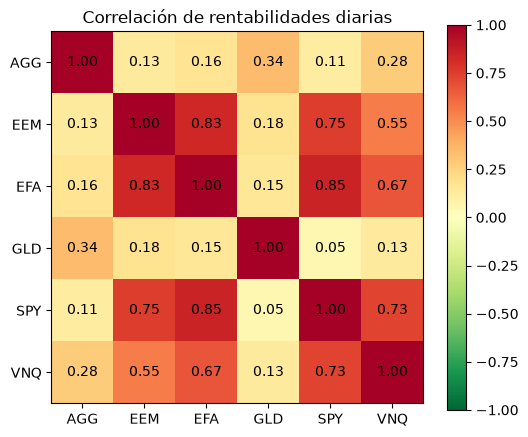

In [93]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="RdYlGn_r", vmin=-1, vmax=1)
ax.set_xticks(range(6), corr.columns)
ax.set_yticks(range(6), corr.index)
for i in range(6):
    for j in range(6):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")
fig.colorbar(im)
ax.set_title("Correlación de rentabilidades diarias")
plt.show()

La matriz de correlaciones muestra tres bloques:

- **Renta variable (EEM, EFA, SPY, VNQ):** correlaciones altas entre sí (hasta 0,85 entre EFA y SPY). Diversifican poco unos de otros.
- **Bonos (AGG):** correlación baja con todo (entre 0,11 y 0,34).
- **Oro (GLD):** la más baja con SPY (0,05).

**Conclusión:** la diversificación viene sobre todo de combinar renta variable con bonos y oro. Limitación: son correlaciones históricas desde 2016 y tienden a subir en las crisis, justo cuando más se necesita diversificar.

### Cartera de pesos iguales

Para ver el efecto de la diversificación, propongo una cartera con el mismo peso (1/6) en cada activo y comparo dos cifras:

- **Media ponderada de las volatilidades individuales** (16,10 %): el riesgo que tendría la cartera si los activos se movieran exactamente igual (correlación +1).
- **Volatilidad real de la cartera** (12,20 %), calculada con la matriz de covarianzas como $\sigma_p = \sqrt{w^\top \Sigma\, w}$.

In [94]:
w = np.repeat(1/6, 6)                     # 1/6 en cada activo

vol_cartera = np.sqrt(w @ cov_anual.values @ w)
vol_media = (w * volatilidad_anual.values).sum()   # media ponderada de vols individuales

vol_cartera, vol_media

(np.float64(0.12204498923882998), np.float64(0.16096849981110006))

**Conclusión:** la cartera es unos 3,9 puntos porcentuales menos volátil que la media de sus componentes, sin renunciar a rentabilidad esperada. Esa diferencia es el **beneficio de la diversificación** y existe porque los activos no están perfectamente correlacionados.

In [95]:
# Guardamos los resultados en CSV para poder usarlos en el siguiente notebook

cov_anual.to_csv("../data/cov_anual.csv")
rentabilidad_anual.to_csv("../data/rentabilidad_anual.csv")